<a href="https://colab.research.google.com/github/SOURAV143-BIT/CUSTOMER-CHURN-PREDICTION-USING-MACHINE-LEARNING/blob/main/CUSTOMER_CHURN_PROJECT_USING_MACHINE_LEARNING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IMPORTING LIBRARIES

In [414]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

loading the dataset

In [415]:
df=pd.read_csv("/content/customer_churn (2).csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


seeing the information of data

In [416]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


● Extracting  the 5th column and storing it in ‘customer_tenture’


In [417]:
customer_tenture=df.iloc[:,5]
customer_tenture

,tenure
0,1
1,34
2,2
3,45
4,2
...,...
7038,24
7039,72
7040,11
7041,4


 Extracting the 15th column and storing it in ‘customer_contract’


In [418]:
customer_contract=df.iloc[:,15]
customer_contract

,Contract
0,Month-to-month
1,One year
2,Month-to-month
3,One year
4,Month-to-month
...,...
7038,One year
7039,One year
7040,Month-to-month
7041,Month-to-month


● Extracting all the male senior citizens whose payment method is electronic
checking and storing the result in ‘senior_male_electronic’


In [419]:
senior_male_electronic=df[(df['gender']=='Male') & (df['SeniorCitizen']==1) & (df['PaymentMethod']=='Electronic check')]
senior_male_electronic

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
20,8779-QRDMV,Male,1,No,No,1,No,No phone service,DSL,No,...,Yes,No,No,Yes,Month-to-month,Yes,Electronic check,39.65,39.65,Yes
55,1658-BYGOY,Male,1,No,No,18,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,95.45,1752.55,Yes
57,5067-XJQFU,Male,1,Yes,Yes,66,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,One year,Yes,Electronic check,108.45,7076.35,No
78,0191-ZHSKZ,Male,1,No,No,30,Yes,No,DSL,Yes,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,74.75,2111.3,No
91,2424-WVHPL,Male,1,No,No,1,Yes,No,Fiber optic,No,...,No,Yes,No,No,Month-to-month,No,Electronic check,74.70,74.7,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6837,6229-LSCKB,Male,1,No,No,6,Yes,No,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Electronic check,79.70,497.6,No
6894,1400-MMYXY,Male,1,Yes,No,3,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,105.90,334.65,Yes
6914,7142-HVGBG,Male,1,Yes,No,43,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,103.00,4414.3,Yes
6967,8739-WWKDU,Male,1,No,No,25,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Electronic check,89.50,2196.15,Yes


● Extracting all those customers whose tenure is greater than 70 months or
their monthly charges is more than $100 and storing the result in
‘customer_total_tenure’

In [420]:
customer_total_tenure=df[(df['tenure']>70) | (df['MonthlyCharges']>100)]
customer_total_tenure

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
12,8091-TTVAX,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,No,Credit card (automatic),100.35,5681.1,No
13,0280-XJGEX,Male,0,No,No,49,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes
14,5129-JLPIS,Male,0,No,No,25,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,105.50,2686.05,No
15,3655-SNQYZ,Female,0,Yes,Yes,69,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),113.25,7895.15,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7023,1035-IPQPU,Female,1,Yes,No,63,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,103.50,6479.4,No
7034,0639-TSIQW,Female,0,No,No,67,Yes,Yes,Fiber optic,Yes,...,Yes,No,Yes,No,Month-to-month,Yes,Credit card (automatic),102.95,6886.25,Yes
7037,2569-WGERO,Female,0,No,No,72,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No



● Extracting all the customers whose contract is of two years, payment method
is mailed check and the value of churn is ‘Yes’ and storing the result in
‘two_mail_yes’


In [421]:
two_mail_yes=df[(df['Contract']=='Two year') & (df['PaymentMethod']=='Mailed check') & (df['Churn']=='Yes')]
two_mail_yes

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
268,6323-AYBRX,Male,0,No,No,59,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.35,1099.6,Yes
5947,7951-QKZPL,Female,0,Yes,Yes,33,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Mailed check,24.50,740.3,Yes
6680,9412-ARGBX,Female,0,No,Yes,48,Yes,No,Fiber optic,No,...,Yes,Yes,Yes,No,Two year,Yes,Mailed check,95.50,4627.85,Yes



● Extracting 333 random records from the customer_churndataframe and storing
the result in ‘customer_333’

In [422]:
customer_333=df.sample(n=333)
customer_333

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
2122,4123-FCVCB,Female,0,No,No,12,Yes,Yes,DSL,No,...,No,Yes,Yes,Yes,One year,Yes,Mailed check,75.85,854.45,No
2358,6974-DAFLI,Female,0,Yes,No,55,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Electronic check,19.70,1140.05,No
5355,4724-WXVWF,Male,0,No,No,48,Yes,Yes,Fiber optic,Yes,...,No,Yes,No,Yes,Month-to-month,Yes,Electronic check,95.40,4445.3,No
457,0942-KOWSM,Female,0,Yes,Yes,30,Yes,No,DSL,No,...,Yes,Yes,Yes,Yes,Two year,No,Bank transfer (automatic),80.80,2369.3,No
3425,0369-ZGOVK,Female,0,Yes,Yes,28,Yes,No,Fiber optic,No,...,No,No,No,No,One year,Yes,Bank transfer (automatic),70.40,1992.2,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
344,5924-SNGKP,Female,0,No,Yes,41,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Credit card (automatic),20.25,865,No
4285,1506-YJTYT,Male,0,Yes,Yes,45,Yes,Yes,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),73.85,3371,No
5130,4625-EWPTF,Male,0,No,No,8,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,30.45,226.45,Yes
1217,0784-GTUUK,Male,0,Yes,No,62,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Credit card (automatic),23.75,1446.8,No



● Geting the count of different levels from the ‘Churn’ column

In [423]:
df.value_counts('Churn')

,count
Churn,
No,5174
Yes,1869


visualising the distribution of internet services

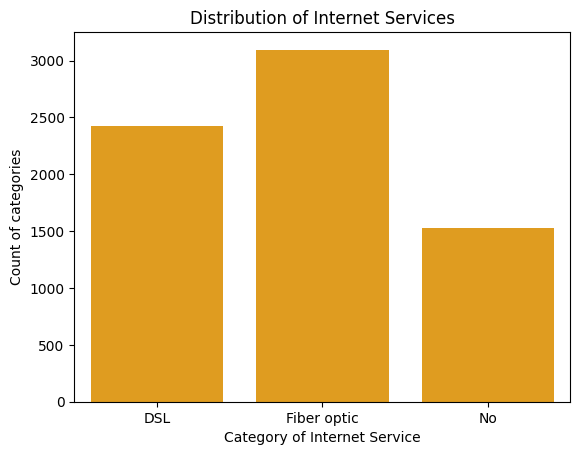

In [424]:
sns.countplot(x='InternetService',data=df,color='orange')
plt.xlabel('Category of Internet Service')
plt.ylabel('Count of categories')
plt.title('Distribution of Internet Services')
plt.show()


visualising the tenure column,setting the bins=30


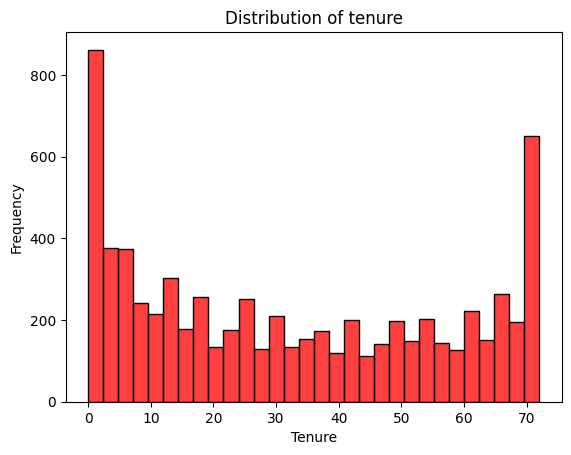

In [425]:

sns.histplot(df['tenure'], bins=30, color='red')
plt.title('Distribution of tenure')
plt.xlabel('Tenure')
plt.ylabel('Frequency')
plt.show()



Building a scatter-plot between ‘MonthlyCharges’ and ‘tenure’.

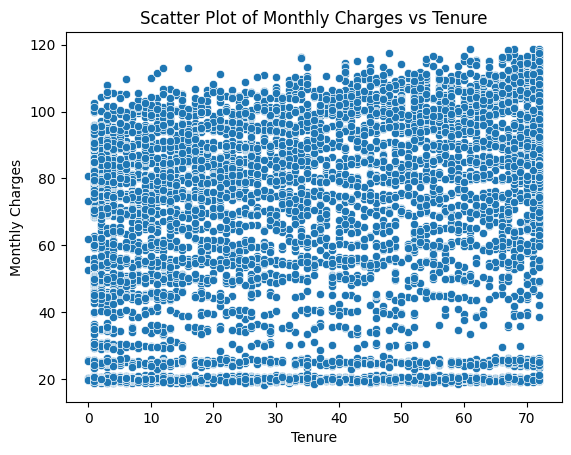

In [426]:
sns.scatterplot(x='tenure',y='MonthlyCharges',data=df)
plt.title('Scatter Plot of Monthly Charges vs Tenure')
plt.xlabel('Tenure')
plt.ylabel('Monthly Charges')
plt.show()

building a box plot b/w tenture and contract

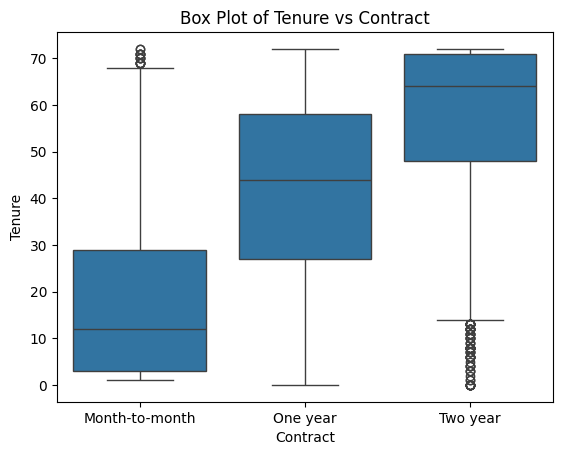

In [427]:
sns.boxplot(x='Contract',y='tenure',data=df)
plt.title('Box Plot of Tenure vs Contract')
plt.xlabel('Contract')
plt.ylabel('Tenure')
plt.show()

# **BUILDING A LINEAR REGRESSION MODEL TO PREDICT THE MONTHLY CHARGES ON THE BASIS OF TENURE*

In [428]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score,root_mean_squared_error,accuracy_score

In [429]:
x=df[['tenure']]
y=df['MonthlyCharges']

In [430]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [431]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((4930, 1), (2113, 1), (4930,), (2113,))

In [432]:
lr=LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [433]:
lr_y_pred=lr.predict(x_test)


In [434]:
lr_y_pred

array([55.10659011, 67.43520921, 70.82557946, ..., 73.29130328,
       60.96268418, 61.57911514])

In [435]:

# Error in prediction
error = y_test - lr_y_pred

print("Prediction Error:")
print(error)


Prediction Error:
185    -30.306590
2715   -42.185209
3825   -51.475579
1807    21.243410
132    -24.898812
          ...    
5522    15.043410
6377   -10.456590
5500   -12.791303
2392    29.737316
6705   -10.479115
Name: MonthlyCharges, Length: 2113, dtype: float64


In [436]:

# Mean Squared Error
mse = mean_squared_error(y_test, lr_y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 845.6091871095867


In [437]:

# Root Mean Square Error
rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 29.07936015646814


# **BUILDING A  SIMPLE LOGISTIC REGRESSION MODEL TO PREDICT CUSTOMER CHURN ,INDEPENDENT VARIABLE IS MONTHLY CHARGES**

In [438]:

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

In [439]:
df['Churn'] = df['Churn'].map({'No':0, 'Yes':1})

In [440]:
x2=df[['MonthlyCharges']]
y2=df['Churn']

In [441]:
x2_train,x2_test,y2_train,y2_test=train_test_split(x2,y2,test_size=0.20,random_state=42)

In [442]:
lg=LogisticRegression()
lg.fit(x2_train,y2_train)

LogisticRegression()

In [443]:
lg_y_pred=lg.predict(x2_test)

In [444]:
lg_acc=accuracy_score(y2_test,lg_y_pred)
lg_acc

0.7352732434350603

In [445]:
lg_cf=confusion_matrix(y2_test,lg_y_pred)
lg_cf

array([[1036,    0],
       [ 373,    0]])

# **BUILDING A MULTI LOGISTIC REGRESSION MODEL TO PREDICT CHURN,WHERE INDEPENDENT VARIABLE IS TENURE AND MONTHLY CHARGES**

In [446]:


X3 = df[['tenure', 'MonthlyCharges']]
y3 = df['Churn']


In [447]:
X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.20, random_state=42)


In [448]:

# Build Model
multi_log_model = LogisticRegression(max_iter=1000)
multi_log_model.fit(X3_train, y3_train)


LogisticRegression(max_iter=1000)

In [449]:

# Predict
multi_lg_y_pred = multi_log_model.predict(X3_test)


In [450]:

multi_lg_cm = confusion_matrix(y3_test,multi_lg_y_pred)
print("Confusion Matrix:")
print(multi_lg_cm)


Confusion Matrix:
[[944  92]
 [193 180]]


In [451]:

# Accuracy Score
multi_lg_accuracy = accuracy_score(y3_test, multi_lg_y_pred)
print("Accuracy Score:", multi_lg_accuracy)

Accuracy Score: 0.7977288857345636


# **BUILDING A DECISION TREE MODEL TO PREDICT CHURN WHERE INDEPENDENT VARIABLE IS TENURE**

In [452]:
from sklearn.tree import DecisionTreeClassifier

In [453]:
x4=df[['tenure']]
y4=df['Churn']

In [454]:
x4_train,x4_test,y4_train,y4_test=train_test_split(x4,y4,test_size=0.3,random_state=42)

In [455]:
dt=DecisionTreeClassifier()
dt.fit(x4_train,y4_train)


DecisionTreeClassifier()

In [456]:
dt_y_pred=dt.predict(x4_test)

In [458]:
dt_acc=accuracy_score(y4_test,dt_y_pred)
dt_acc

0.7510648367250355

In [459]:
dt_cf=confusion_matrix(y4_test,dt_y_pred)
dt_cf

array([[1399,  140],
       [ 386,  188]])

# **BUILDING A RANDOM FOREST MODEL TO PREDICT CHURN WHERE INDEPENDENT VARIABLES ARE TENURE AND MONTHLY CHARGES**

In [460]:
from sklearn.ensemble import RandomForestClassifier

In [461]:
x5=df[['tenure','MonthlyCharges']]
y5=df['Churn']

In [462]:
x5_train,x5_test,y5_train,y5_test=train_test_split(x5,y5,test_size=0.3,random_state=42)

In [463]:
rfc=RandomForestClassifier()
rfc.fit(x5_train,y5_train)

RandomForestClassifier()

In [464]:
rfc_y_pred=rfc.predict(x5_test)

In [465]:
rfc_y_pred_ACC=accuracy_score(y5_test,rfc_y_pred)
print(rfc_y_pred_ACC)


0.759110269758637


In [467]:
RFC_CF=confusion_matrix(y5_test,rfc_y_pred)
print(RFC_CF)

[[1335  204]
 [ 305  269]]


### Model Performance Comparison



/tmp/ipykernel_3048/1479481647.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette='viridis')


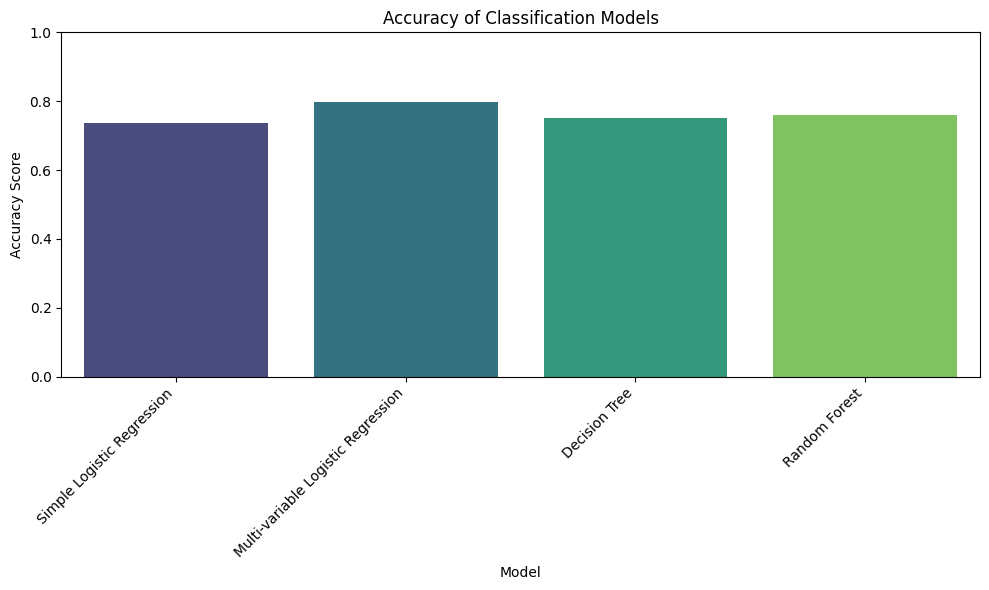

In [468]:
models = ['Simple Logistic Regression', 'Multi-variable Logistic Regression', 'Decision Tree', 'Random Forest']
accuracies = [lg_acc, multi_lg_accuracy, dt_acc, rfc_y_pred_ACC]

plt.figure(figsize=(10, 6))
sns.barplot(x=models, y=accuracies, palette='viridis')
plt.title('Accuracy of Classification Models')
plt.xlabel('Model')
plt.ylabel('Accuracy Score')
plt.xticks(rotation=45, ha='right')
plt.show()